# 🐦 Twitter Post Classifier — Complete ML Pipeline
### Project: Web/App Development Lead Intelligence System

**Goal:** Classify tweets related to web/app development into 5 business-relevant categories, filtering out noise.

**Categories:**
- `0` → **irrelevant** (filtered out — scams, rants, unrelated content)
- `1` → **launch** (someone launched/built an app or website)
- `2` → **hiring** (someone looking to hire a developer)
- `3` → **build_request** (someone needs an app/website built)
- `4` → **progress_update** (sharing metrics/milestones on existing product)
- `5` → **industry_news** (news about apps/websites/tech industry)

**Dataset:** 1012 tweets (767 real, scraped via Twitter API + 245 synthetic examples), manually labeled and reviewed.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                                ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                               confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Step 2 — Load Dataset & Exploratory Data Analysis

In [2]:
df = pd.read_csv('final_dataset.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1012, 5)


,profile_name,username,text,label,label_name
0,Matthew Turley,matthewrturley,A founder paid me to scan their AI-built app. ...,0,irrelevant
1,SirMarty,MartyBee_,"@UniverseIce Its a user friendly, well built a...",0,irrelevant
2,Erik Anderson,primex001,The full 12-point checklist I run before real ...,0,irrelevant
3,Lars Jansen,oldstackjournal,The useful part of a simple stack isn’t nostal...,0,irrelevant
4,Upsilon,upsilon_it,Your #AI built app works perfectly... until re...,0,irrelevant


In [3]:
print('Class distribution:')
print(df['label_name'].value_counts())
print()
print('Missing values:', df.isnull().sum().sum())

Class distribution:
label_name
irrelevant         486
launch             139
progress_update    136
hiring             124
industry_news       77
build_request       50
Name: count, dtype: int64

Missing values: 0


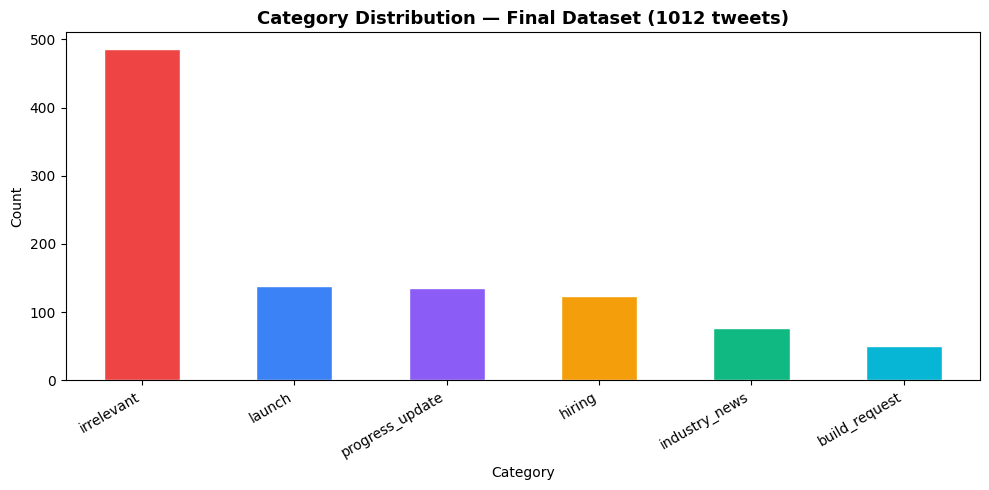

In [4]:
plt.figure(figsize=(10,5))
colors = ['#ef4444', '#3b82f6', '#8b5cf6', '#f59e0b', '#10b981', '#06b6d4']
df['label_name'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Category Distribution — Final Dataset (1012 tweets)', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('nb_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
print(df.groupby('label_name')[['text_length', 'word_count']].mean().round(1))

                 text_length  word_count
label_name                              
build_request          442.4        70.8
hiring                 383.3        57.3
industry_news          257.7        40.6
irrelevant             302.0        48.0
launch                 310.6        47.1
progress_update        238.0        37.8


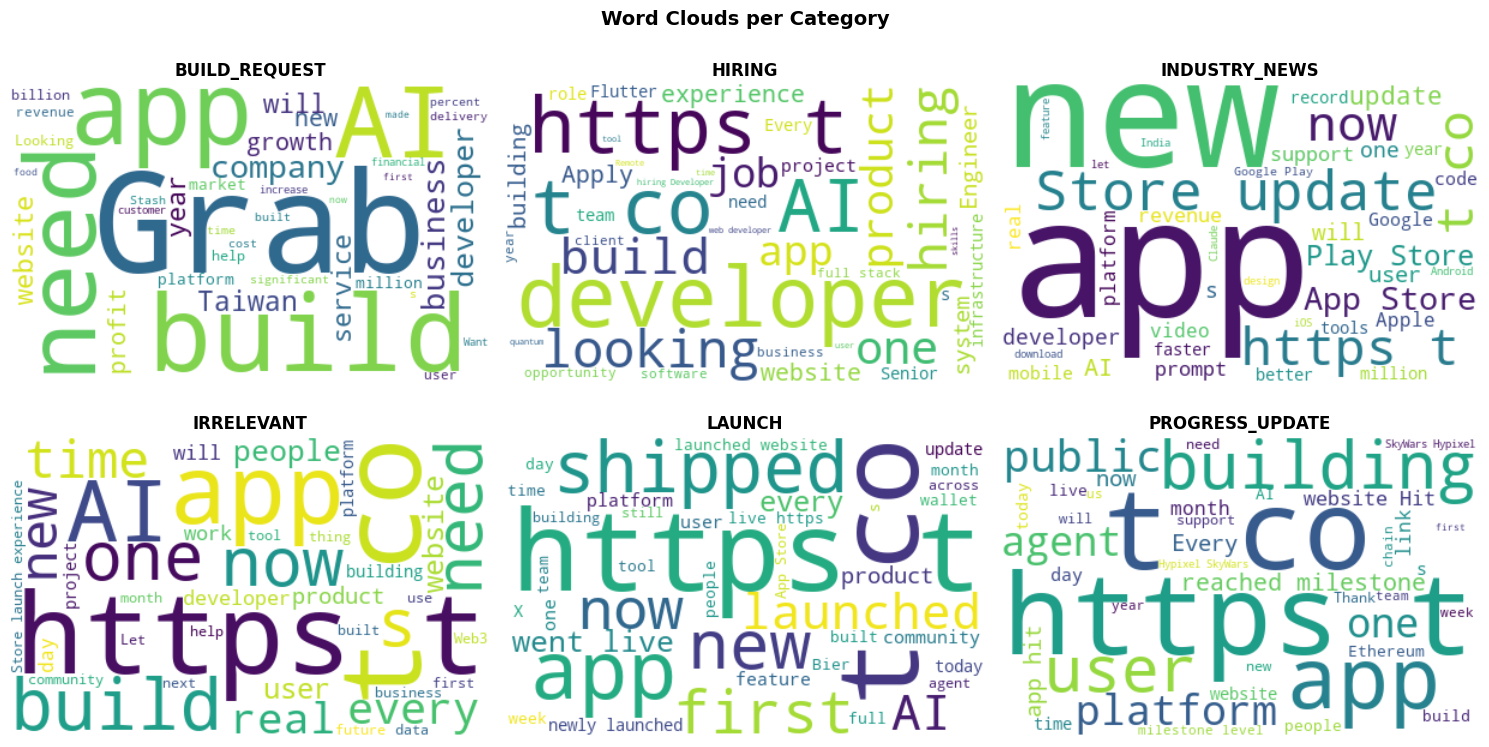

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (label_name, group) in enumerate(df.groupby('label_name')):
    text = ' '.join(group['text'].astype(str).values)
    wc = WordCloud(width=400, height=250, background_color='white', max_words=40, colormap='viridis').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{label_name.upper()}', fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Word Clouds per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Text Preprocessing (NLP)

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
keep_words = {'not', 'no', 'never', 'need', 'want', 'looking', 'building', 'built', 'hire', 'hiring'}
stop_words -= keep_words

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[@#]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)
df = df[df['clean_text'].str.len() > 3].reset_index(drop=True)

print('✅ Preprocessing done')
print('\nOriginal:', df['text'].iloc[0][:100])
print('Cleaned: ', df['clean_text'].iloc[0][:100])
print('\nDataset shape after cleaning:', df.shape)

✅ Preprocessing done

Original: A founder paid me to scan their AI-built app. 41 issues came back.  What they thanked me for wasn't 
Cleaned:  founder paid scan aibuilt app issue came back thanked wasnt issue line said fix today ignore hand re

Dataset shape after cleaning: (1012, 8)


## Step 4 — Feature Engineering (TF-IDF) & Train/Test Split

In [8]:
label_map = {0: 'irrelevant', 1: 'launch', 2: 'hiring', 3: 'build_request', 4: 'progress_update', 5: 'industry_news'}

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training samples: {len(X_train)}')
print(f'Testing samples : {len(X_test)}')

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('\nClass weights (to handle imbalance):')
for cls, w in class_weight_dict.items():
    print(f'  {label_map[cls]:16}: {w:.3f}')

Training samples: 809
Testing samples : 203

Class weights (to handle imbalance):
  irrelevant      : 0.348
  launch          : 1.215
  hiring          : 1.362
  build_request   : 3.371
  progress_update : 1.237
  industry_news   : 2.175


In [9]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
X_all_vec = tfidf.transform(X)

print(f'TF-IDF Matrix Shape: {X_train_vec.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')

TF-IDF Matrix Shape: (809, 5000)
Vocabulary size: 5000


## Step 5 — Train & Compare 15 ML Algorithms

We train every major classical ML algorithm suited for text classification and compare them using 5-fold cross-validated F1-macro score (more reliable than raw accuracy given class imbalance).

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight=class_weight_dict),
    'Linear SVM': LinearSVC(random_state=42, class_weight=class_weight_dict, max_iter=2000),
    'SVM (RBF kernel)': SVC(kernel='rbf', random_state=42, class_weight=class_weight_dict),
    'SGD Classifier': SGDClassifier(random_state=42, class_weight=class_weight_dict, loss='log_loss'),
    'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    'Naive Bayes (Complement)': ComplementNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight=class_weight_dict),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight=class_weight_dict),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
}

print(f'Training {len(models)} algorithms...\n')

Training 15 algorithms...



In [11]:
results = []
for name, clf in models.items():
    t0 = time.time()
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    cv_f1 = cross_val_score(clf, X_all_vec, y, cv=5, scoring='f1_macro').mean()
    elapsed = time.time() - t0
    results.append({
        'Model': name, 'Test Accuracy': acc, 'Test F1-Macro': f1_macro,
        'CV F1-Macro': cv_f1, 'Time (s)': elapsed
    })
    print(f'{name:28} | Acc: {acc:.3f} | F1-macro: {f1_macro:.3f} | CV F1: {cv_f1:.3f} | {elapsed:.1f}s')

results_df = pd.DataFrame(results).sort_values('CV F1-Macro', ascending=False).reset_index(drop=True)

Logistic Regression          | Acc: 0.729 | F1-macro: 0.663 | CV F1: 0.567 | 0.4s
Linear SVM                   | Acc: 0.749 | F1-macro: 0.690 | CV F1: 0.543 | 0.1s
SVM (RBF kernel)             | Acc: 0.704 | F1-macro: 0.615 | CV F1: 0.421 | 1.0s
SGD Classifier               | Acc: 0.754 | F1-macro: 0.698 | CV F1: 0.541 | 0.0s
Naive Bayes (Multinomial)    | Acc: 0.680 | F1-macro: 0.564 | CV F1: 0.453 | 0.0s
Naive Bayes (Complement)     | Acc: 0.700 | F1-macro: 0.631 | CV F1: 0.421 | 0.0s
Random Forest                | Acc: 0.714 | F1-macro: 0.610 | CV F1: 0.484 | 2.8s
Extra Trees                  | Acc: 0.734 | F1-macro: 0.630 | CV F1: 0.488 | 4.5s
Gradient Boosting            | Acc: 0.744 | F1-macro: 0.659 | CV F1: 0.490 | 11.5s
AdaBoost                     | Acc: 0.537 | F1-macro: 0.326 | CV F1: 0.298 | 0.7s
Decision Tree                | Acc: 0.665 | F1-macro: 0.597 | CV F1: 0.480 | 0.2s
K-Nearest Neighbors          | Acc: 0.695 | F1-macro: 0.622 | CV F1: 0.454 | 0.0s
Neural Network 

In [12]:
print('='*90)
print('FULL MODEL COMPARISON — RANKED BY CV F1-MACRO')
print('='*90)
results_df

FULL MODEL COMPARISON — RANKED BY CV F1-MACRO


,Model,Test Accuracy,Test F1-Macro,CV F1-Macro,Time (s)
0,Logistic Regression,0.729064,0.662778,0.567357,0.391245
1,Linear SVM,0.748768,0.689515,0.543025,0.083683
2,SGD Classifier,0.753695,0.698087,0.541282,0.029820
3,XGBoost,0.748768,0.675433,0.521220,5.210993
4,LightGBM,0.714286,0.628363,0.511449,14.860804
5,Gradient Boosting,0.743842,0.658526,0.489967,11.463828
6,Extra Trees,0.733990,0.629816,0.487769,4.459599
7,Random Forest,0.714286,0.609779,0.484327,2.805441
8,Decision Tree,0.665025,0.597191,0.479585,0.169956
9,Neural Network (MLP),0.694581,0.610498,0.461274,7.725099


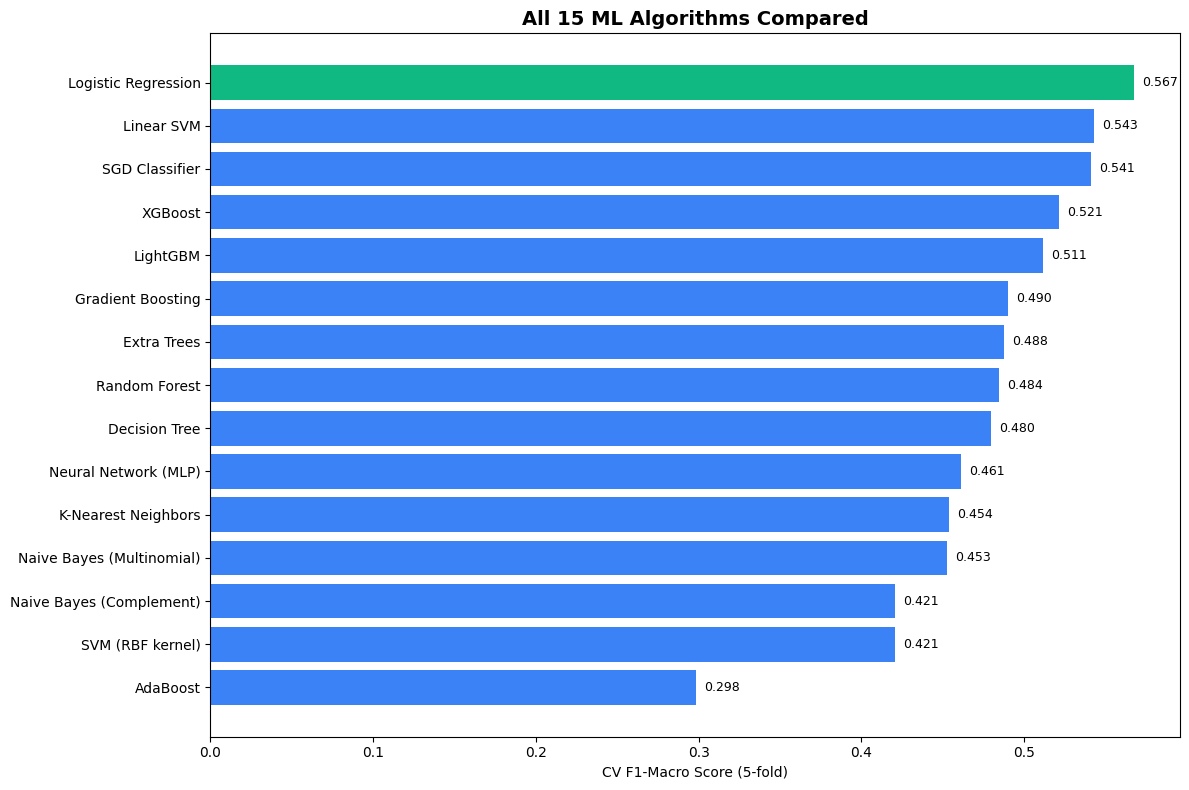


🏆 Best Model: Logistic Regression
   CV F1-Macro: 0.5674


In [13]:
fig, ax = plt.subplots(figsize=(12,8))
colors_bar = ['#10b981' if i==0 else '#3b82f6' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['CV F1-Macro'], color=colors_bar)
ax.set_xlabel('CV F1-Macro Score (5-fold)')
ax.set_title('All 15 ML Algorithms Compared', fontweight='bold', fontsize=14)
ax.invert_yaxis()
for bar, val in zip(bars, results_df['CV F1-Macro']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('nb_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   CV F1-Macro: {results_df.iloc[0]['CV F1-Macro']:.4f}")

## Step 6 — Hyperparameter Tuning (GridSearchCV on Best Model)

In [14]:
best_model_name = results_df.iloc[0]['Model']
print(f'Tuning: {best_model_name}')

param_grid = {
    'clf__C': [0.5, 1.0, 5.0, 10.0],
    'tfidf__max_features': [3000, 5000, 7000],
}

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight=class_weight_dict))
])

grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'\n🏆 Best Parameters: {grid_search.best_params_}')
print(f'   Best CV F1-Macro: {grid_search.best_score_:.4f}')

Tuning: Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

🏆 Best Parameters: {'clf__C': 10.0, 'tfidf__max_features': 5000}
   Best CV F1-Macro: 0.7160


## Step 7 — Final Model Evaluation

In [15]:
final_model = grid_search.best_estimator_
final_preds = final_model.predict(X_test)

print(f'Final Test Accuracy: {accuracy_score(y_test, final_preds):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, final_preds, target_names=[label_map[i] for i in sorted(label_map.keys())]))

Final Test Accuracy: 0.7488

Classification Report:
                 precision    recall  f1-score   support

     irrelevant       0.79      0.85      0.82        98
         launch       0.67      0.50      0.57        28
         hiring       0.81      0.84      0.82        25
  build_request       0.50      0.70      0.58        10
progress_update       0.78      0.67      0.72        27
  industry_news       0.64      0.60      0.62        15

       accuracy                           0.75       203
      macro avg       0.70      0.69      0.69       203
   weighted avg       0.75      0.75      0.75       203



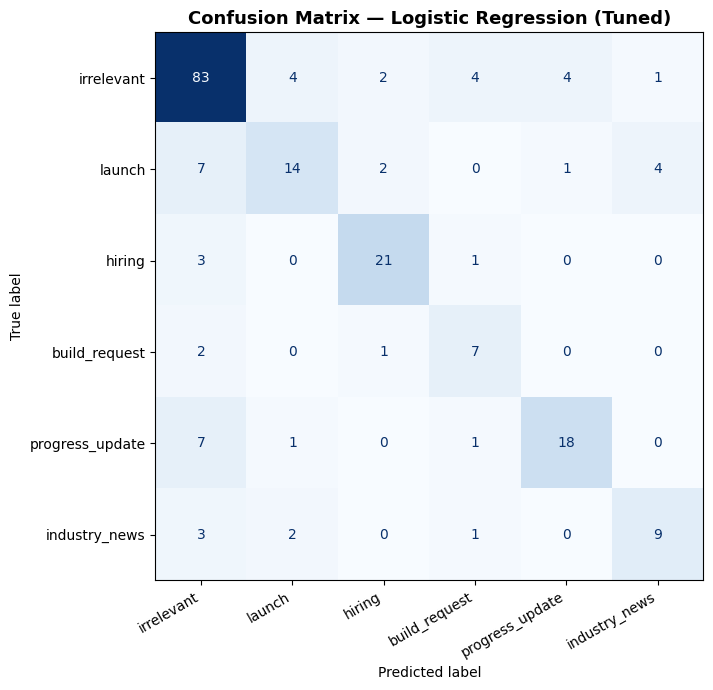

In [16]:
cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(9,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_map[i] for i in sorted(label_map.keys())])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — {best_model_name} (Tuned)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('nb_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Lead Scoring System

In [17]:
CATEGORY_WEIGHTS = {
    0: 0,    # irrelevant
    1: 70,   # launch
    2: 95,   # hiring
    3: 100,  # build_request
    4: 50,   # progress_update
    5: 40,   # industry_news
}

def calculate_lead_score(text, model):
    clean = preprocess(text)
    proba = model.predict_proba([clean])[0]
    predicted_class = int(model.predict([clean])[0])
    confidence = float(proba[predicted_class])
    base_score = CATEGORY_WEIGHTS[predicted_class]
    lead_score = round(base_score * confidence)
    return {
        'predicted_label': label_map[predicted_class],
        'confidence': round(confidence * 100, 1),
        'lead_score': lead_score,
        'is_relevant': predicted_class != 0
    }

test_tweets = [
    'Need someone to build an e-commerce website for my clothing brand urgently',
    'This app is a complete scam stole my money avoid it',
    'Just launched our fintech app on Play Store after 6 months of work',
    'Hiring senior React developer for our startup remote friendly apply now',
    'Hit 10000 users on our platform this month incredible milestone',
    'Google just announced major changes to Play Store policies for developers',
]

print('Lead Scoring Demo:')
print('-'*75)
for tweet in test_tweets:
    result = calculate_lead_score(tweet, final_model)
    status = '✅' if result['is_relevant'] else '❌'
    print(f"{status} [{result['predicted_label'].upper():16}] Score: {result['lead_score']:3}/100 | {tweet[:45]}")

Lead Scoring Demo:
---------------------------------------------------------------------------
✅ [BUILD_REQUEST   ] Score:  98/100 | Need someone to build an e-commerce website f
❌ [IRRELEVANT      ] Score:   0/100 | This app is a complete scam stole my money av
✅ [LAUNCH          ] Score:  60/100 | Just launched our fintech app on Play Store a
✅ [HIRING          ] Score:  89/100 | Hiring senior React developer for our startup
✅ [PROGRESS_UPDATE ] Score:  50/100 | Hit 10000 users on our platform this month in
✅ [INDUSTRY_NEWS   ] Score:  36/100 | Google just announced major changes to Play S


## Step 9 — Save Final Model for Deployment

In [18]:
joblib.dump(final_model, 'tweet_classifier_final.pkl')
joblib.dump(label_map, 'label_map.pkl')
joblib.dump(CATEGORY_WEIGHTS, 'category_weights.pkl')
results_df.to_csv('all_models_comparison.csv', index=False)

print('✅ Model saved as tweet_classifier_final.pkl')
print('✅ All artifacts saved for deployment')

loaded_model = joblib.load('tweet_classifier_final.pkl')
test_pred = loaded_model.predict([preprocess('Need a developer to build my app')])
print(f"\nVerification: 'Need a developer to build my app' -> {label_map[int(test_pred[0])]}")

✅ Model saved as tweet_classifier_final.pkl
✅ All artifacts saved for deployment

Verification: 'Need a developer to build my app' -> build_request


## Summary

In [19]:
print('='*70)
print('              PROJECT ML PIPELINE — FINAL SUMMARY')
print('='*70)
print(f'Dataset Size        : {len(df)} labeled tweets (real + synthetic)')
print(f'Categories          : 6 (5 business-relevant + 1 filter)')
print(f'Algorithms Compared : {len(models)}')
print(f'Best Algorithm      : {best_model_name}')
print(f'Best CV F1-Macro    : {results_df.iloc[0]["CV F1-Macro"]:.4f}')
print(f'Final Test Accuracy : {accuracy_score(y_test, final_preds):.4f}')
print(f'Tuned Hyperparams   : {grid_search.best_params_}')
print('='*70)

              PROJECT ML PIPELINE — FINAL SUMMARY
Dataset Size        : 1012 labeled tweets (real + synthetic)
Categories          : 6 (5 business-relevant + 1 filter)
Algorithms Compared : 15
Best Algorithm      : Logistic Regression
Best CV F1-Macro    : 0.5674
Final Test Accuracy : 0.7488
Tuned Hyperparams   : {'clf__C': 10.0, 'tfidf__max_features': 5000}
